In [1]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path("output/test_count_aggregate.csv")
df = pd.read_csv(CSV_PATH)

print(df.shape)
df.head()


(801, 11)


,Model,Context,Instance,TestFileCount,TotalTestCount,CompiledTestFileCount,CompiledTestCount,ExecutedTestFileCount,ExecutedTestCount,DetectedTestFileCount,DetectedBCTestCount
0,GPT4o,Class,BBC01,1,1,NOT_COMPILED,NOT_COMPILED,NOT_VALID,NOT_VALID,NOT_VALID,NOT_VALID
1,GPT4o,Class,BBC02,2,2,NOT_COMPILED,NOT_COMPILED,NOT_VALID,NOT_VALID,NOT_VALID,NOT_VALID
2,GPT4o,Class,BBC03,2,2,1,1,1,1,1,1
3,GPT4o,Class,BBC04,51,91,1,1,1,1,0,0
4,GPT4o,Class,BBC05,4,6,NOT_COMPILED,NOT_COMPILED,NOT_VALID,NOT_VALID,NOT_VALID,NOT_VALID


In [2]:
# confirm which columns have string values
print(df.dtypes)
print()
for col in ["CompiledTestFileCount", "CompiledTestCount", "ExecutedTestFileCount",
            "ExecutedTestCount", "DetectedTestFileCount", "DetectedBCTestCount"]:
    print(col, "->", df[col].unique()[:5])


Model                    object
Context                  object
Instance                 object
TestFileCount             int64
TotalTestCount            int64
CompiledTestFileCount    object
CompiledTestCount        object
ExecutedTestFileCount    object
ExecutedTestCount        object
DetectedTestFileCount    object
DetectedBCTestCount      object
dtype: object

CompiledTestFileCount -> ['NOT_COMPILED' '1' '49' '2' '247']
CompiledTestCount -> ['NOT_COMPILED' '1' '119' '2' '492']
ExecutedTestFileCount -> ['NOT_VALID' '1' '16' '0' '171']
ExecutedTestCount -> ['NOT_VALID' '1' '36' '0' '278']
DetectedTestFileCount -> ['NOT_VALID' '1' '0' '16' '2']
DetectedBCTestCount -> ['NOT_VALID' '1' '0' '36' '2']


Adding 0 as cannot drop the rows, it will miscalculate stuff.

In [3]:
SENTINELS = {"NOT_COMPILED": 0, "NOT_VALID": 0}
NUMERIC_COLS = ["TestFileCount", "TotalTestCount", "CompiledTestFileCount", "CompiledTestCount",
                "ExecutedTestFileCount", "ExecutedTestCount", "DetectedTestFileCount", "DetectedBCTestCount"]

df_clean = df.copy()
for col in NUMERIC_COLS:
    df_clean[col] = df_clean[col].replace(SENTINELS).astype(int)

df_clean.dtypes


Model                    object
Context                  object
Instance                 object
TestFileCount             int64
TotalTestCount            int64
CompiledTestFileCount     int64
CompiledTestCount         int64
ExecutedTestFileCount     int64
ExecutedTestCount         int64
DetectedTestFileCount     int64
DetectedBCTestCount       int64
dtype: object

In [4]:
NUMERIC_COLS = ["TestFileCount", "TotalTestCount", "CompiledTestFileCount", "CompiledTestCount",
                "ExecutedTestFileCount", "ExecutedTestCount", "DetectedTestFileCount", "DetectedBCTestCount"]

modelcontext_df = (
    df_clean
    .groupby(["Model", "Context"], as_index=False)[NUMERIC_COLS]
    .sum()
)

modelcontext_df


,Model,Context,TestFileCount,TotalTestCount,CompiledTestFileCount,CompiledTestCount,ExecutedTestFileCount,ExecutedTestCount,DetectedTestFileCount,DetectedBCTestCount
0,GPT4o,Class,5790,9841,1868,3178,968,1528,335,452
1,GPT4o,Method,5790,10252,1684,2845,827,1190,301,393
2,GPT4o,Minimal,5790,6904,1014,1146,414,449,174,178
3,GPTOSS,Class,5790,12382,214,396,150,310,69,109
4,GPTOSS,Method,5790,11287,199,325,108,191,78,126
5,GPTOSS,Minimal,5790,8419,117,157,23,30,8,10
6,Qwen3-coder,Class,5790,14281,1939,4043,1293,2510,727,907
7,Qwen3-coder,Method,5790,12981,1802,3142,1020,1644,671,862
8,Qwen3-coder,Minimal,5790,10285,1721,2291,886,1181,673,717


In [5]:
df_clean.head()
print(df_clean.shape)  # should still be (802, 11)


(801, 11)


In [6]:
modelcontext_df = (
    df_clean
    .groupby(["Model", "Context"])
    .agg(
        InstanceCount=("Instance", "nunique"),
        **{col: (col, "sum") for col in NUMERIC_COLS}
    )
    .reset_index()
)

modelcontext_df


,Model,Context,InstanceCount,TestFileCount,TotalTestCount,CompiledTestFileCount,CompiledTestCount,ExecutedTestFileCount,ExecutedTestCount,DetectedTestFileCount,DetectedBCTestCount
0,GPT4o,Class,89,5790,9841,1868,3178,968,1528,335,452
1,GPT4o,Method,89,5790,10252,1684,2845,827,1190,301,393
2,GPT4o,Minimal,89,5790,6904,1014,1146,414,449,174,178
3,GPTOSS,Class,89,5790,12382,214,396,150,310,69,109
4,GPTOSS,Method,89,5790,11287,199,325,108,191,78,126
5,GPTOSS,Minimal,89,5790,8419,117,157,23,30,8,10
6,Qwen3-coder,Class,89,5790,14281,1939,4043,1293,2510,727,907
7,Qwen3-coder,Method,89,5790,12981,1802,3142,1020,1644,671,862
8,Qwen3-coder,Minimal,89,5790,10285,1721,2291,886,1181,673,717


In [7]:
df_clean["ReachedGenerated"] = df_clean["TestFileCount"] > 0
df_clean["ReachedCompiled"]  = df_clean["CompiledTestFileCount"] > 0
df_clean["ReachedExecuted"]  = df_clean["ExecutedTestFileCount"] > 0
df_clean["ReachedDetectedBC"] = df_clean["DetectedBCTestCount"] > 0

df_clean[["Model", "Context", "Instance", "ReachedGenerated", "ReachedCompiled", "ReachedExecuted", "ReachedDetectedBC"]].head()


,Model,Context,Instance,ReachedGenerated,ReachedCompiled,ReachedExecuted,ReachedDetectedBC
0,GPT4o,Class,BBC01,True,False,False,False
1,GPT4o,Class,BBC02,True,False,False,False
2,GPT4o,Class,BBC03,True,True,True,True
3,GPT4o,Class,BBC04,True,True,True,False
4,GPT4o,Class,BBC05,True,False,False,False


In [8]:
STAGE_FLAGS = ["ReachedGenerated", "ReachedCompiled", "ReachedExecuted", "ReachedDetectedBC"]

modelcontext_df = (
    df_clean
    .groupby(["Model", "Context"])
    .agg(
        InstanceCount=("Instance", "nunique"),
        InstancesGenerated=("ReachedGenerated", "sum"),
        InstancesCompiled=("ReachedCompiled", "sum"),
        InstancesExecuted=("ReachedExecuted", "sum"),
        InstancesDetectedBC=("ReachedDetectedBC", "sum"),
        **{col: (col, "sum") for col in NUMERIC_COLS}
    )
    .reset_index()
)

modelcontext_df


,Model,Context,InstanceCount,InstancesGenerated,InstancesCompiled,InstancesExecuted,InstancesDetectedBC,TestFileCount,TotalTestCount,CompiledTestFileCount,CompiledTestCount,ExecutedTestFileCount,ExecutedTestCount,DetectedTestFileCount,DetectedBCTestCount
0,GPT4o,Class,89,89,39,29,27,5790,9841,1868,3178,968,1528,335,452
1,GPT4o,Method,89,89,39,33,13,5790,10252,1684,2845,827,1190,301,393
2,GPT4o,Minimal,89,89,42,36,17,5790,6904,1014,1146,414,449,174,178
3,GPTOSS,Class,89,89,24,20,10,5790,12382,214,396,150,310,69,109
4,GPTOSS,Method,89,89,20,17,8,5790,11287,199,325,108,191,78,126
5,GPTOSS,Minimal,89,89,24,8,4,5790,8419,117,157,23,30,8,10
6,Qwen3-coder,Class,89,89,37,32,20,5790,14281,1939,4043,1293,2510,727,907
7,Qwen3-coder,Method,89,89,37,32,20,5790,12981,1802,3142,1020,1644,671,862
8,Qwen3-coder,Minimal,89,89,36,30,18,5790,10285,1721,2291,886,1181,673,717


create some distribution plot for each model and context variant to see how many tests they generated per instance like a violin plot.

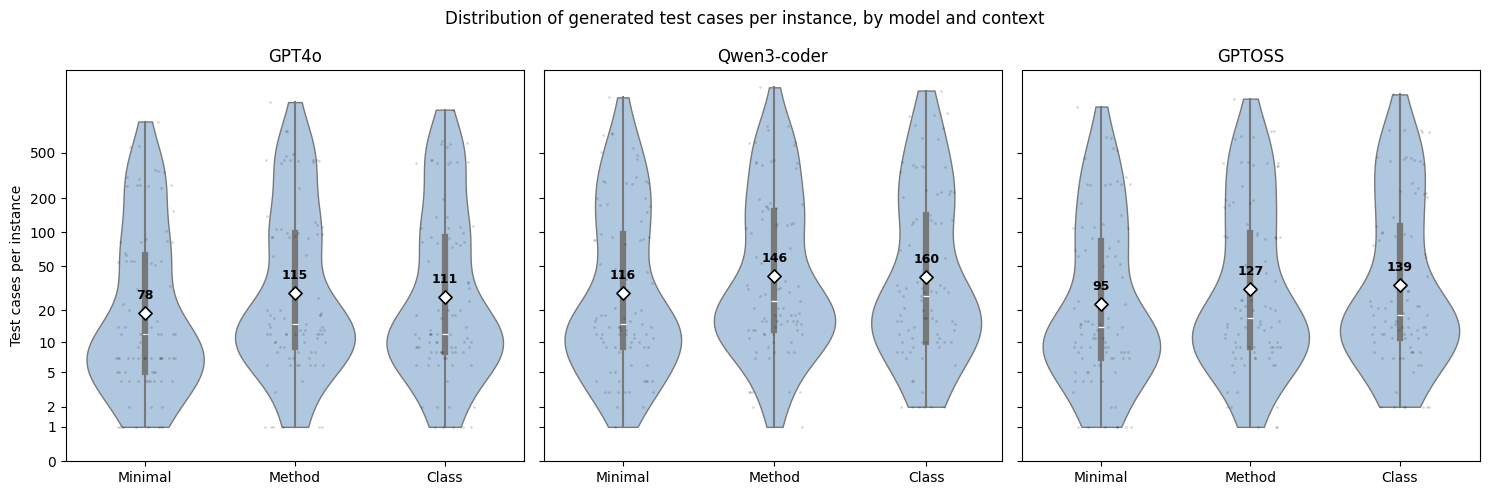

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_ORDER = ["GPT4o", "Qwen3-coder", "GPTOSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

plot_df = df_clean.copy()
plot_df["LogTotalTestCount"] = np.log1p(plot_df["TotalTestCount"])

raw_ticks = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500]
raw_ticks = [t for t in raw_ticks if t <= plot_df["TotalTestCount"].max()]
log_ticks = np.log1p(raw_ticks)

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    sub = plot_df[plot_df["Model"] == model]

    sns.violinplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, cut=0, inner="box",
        color="#a8c6e8", linewidth=1, ax=ax,
    )

    sns.stripplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax,
        color="black", alpha=0.15, size=2, jitter=0.2,
    )

    means = sub.groupby("Context")["LogTotalTestCount"].mean().reindex(CONTEXT_ORDER)
    raw_means = sub.groupby("Context")["TotalTestCount"].mean().reindex(CONTEXT_ORDER)
    for i, ctx in enumerate(CONTEXT_ORDER):
        ax.scatter(i, means[ctx], marker="D", s=45, color="white",
                   edgecolor="black", linewidth=1.2, zorder=5)
        ax.annotate(f"{raw_means[ctx]:.0f}", (i, means[ctx]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", zorder=6)

    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].set_ylabel("Test cases per instance")
axes[0].set_yticks(log_ticks)
axes[0].set_yticklabels(raw_ticks)

fig.suptitle("Distribution of generated test cases per instance, by model and context")
fig.tight_layout()
plt.savefig("output/testcount_violin_by_model_context.png", dpi=150, bbox_inches="tight")
plt.show()

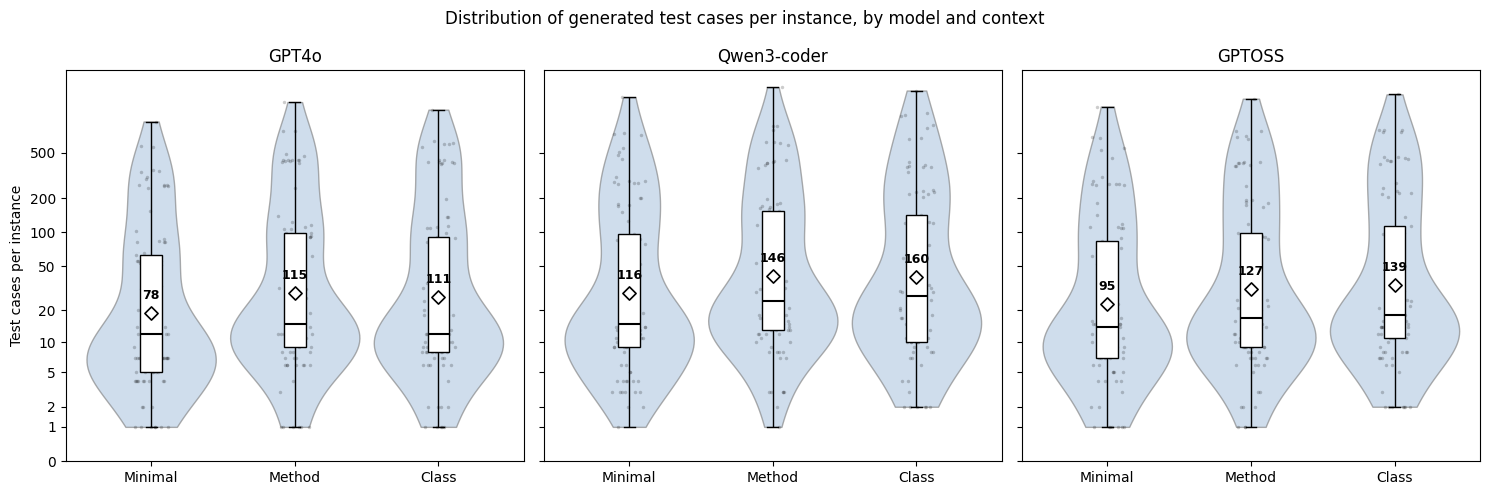

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_ORDER = ["GPT4o", "Qwen3-coder", "GPTOSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

plot_df = df_clean.copy()
plot_df["LogTotalTestCount"] = np.log1p(plot_df["TotalTestCount"])

raw_ticks = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500]
raw_ticks = [t for t in raw_ticks if t <= plot_df["TotalTestCount"].max()]
log_ticks = np.log1p(raw_ticks)

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    sub = plot_df[plot_df["Model"] == model]

    # half-violin (cloud), shifted right so it doesn't overlap the box
    sns.violinplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, cut=0, inner=None,
        color="#a8c6e8", linewidth=1, ax=ax,
        density_norm="width", width=0.9,
    )
    # shrink and shift each violin half to one side
    for coll in ax.collections:
        coll.set_alpha(0.6)

    # boxplot (narrow, offset left) for exact quartiles
    sns.boxplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax, width=0.15,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black"), capprops=dict(color="black"),
        showfliers=False, zorder=3,
    )

    # raw points (rain), jittered below
    sns.stripplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax,
        color="black", alpha=0.2, size=2.5, jitter=0.12, zorder=1,
    )

    means = sub.groupby("Context")["LogTotalTestCount"].mean().reindex(CONTEXT_ORDER)
    raw_means = sub.groupby("Context")["TotalTestCount"].mean().reindex(CONTEXT_ORDER)
    for i, ctx in enumerate(CONTEXT_ORDER):
        ax.scatter(i, means[ctx], marker="D", s=45, color="white",
                   edgecolor="black", linewidth=1.2, zorder=5)
        ax.annotate(f"{raw_means[ctx]:.0f}", (i, means[ctx]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", zorder=6)

    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].set_ylabel("Test cases per instance")
axes[0].set_yticks(log_ticks)
axes[0].set_yticklabels(raw_ticks)

fig.suptitle("Distribution of generated test cases per instance, by model and context")
fig.tight_layout()
plt.savefig("output/testcount_raincloud_by_model_context.png", dpi=150, bbox_inches="tight")
plt.show()

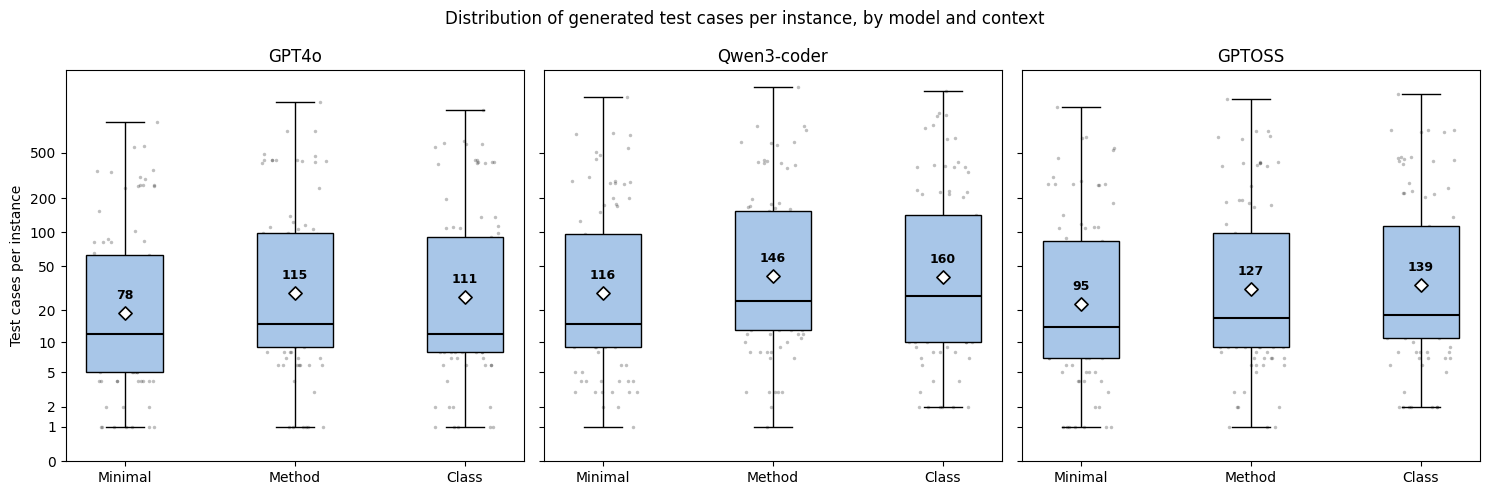

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_ORDER = ["GPT4o", "Qwen3-coder", "GPTOSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

plot_df = df_clean.copy()
plot_df["LogTotalTestCount"] = np.log1p(plot_df["TotalTestCount"])

raw_ticks = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500]
raw_ticks = [t for t in raw_ticks if t <= plot_df["TotalTestCount"].max()]
log_ticks = np.log1p(raw_ticks)

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    sub = plot_df[plot_df["Model"] == model]

    sns.boxplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax, width=0.45,
        boxprops=dict(facecolor="#a8c6e8", edgecolor="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black"), capprops=dict(color="black"),
        showfliers=False, zorder=2,
    )

    # raw points, jittered, sparse enough to read as texture not clutter
    sns.stripplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax,
        color="black", alpha=0.25, size=2.5, jitter=0.2, zorder=1,
    )

    # mean marker + numeric label per context
    means = sub.groupby("Context")["LogTotalTestCount"].mean().reindex(CONTEXT_ORDER)
    raw_means = sub.groupby("Context")["TotalTestCount"].mean().reindex(CONTEXT_ORDER)
    for i, ctx in enumerate(CONTEXT_ORDER):
        ax.scatter(i, means[ctx], marker="D", s=45, color="white",
                   edgecolor="black", linewidth=1.2, zorder=5)
        ax.annotate(f"{raw_means[ctx]:.0f}", (i, means[ctx]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", zorder=6)

    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].set_ylabel("Test cases per instance")
axes[0].set_yticks(log_ticks)
axes[0].set_yticklabels(raw_ticks)

fig.suptitle("Distribution of generated test cases per instance, by model and context")
fig.tight_layout()
plt.savefig("output/testcount_box_by_model_context.png", dpi=150, bbox_inches="tight")
plt.show()

Distribution of generated test count **per focal method** (one generated test file = one usage/call-site = one focal method), grouped by test-count bucket, faceted by model, bars grouped by context. Unlike the per-instance sums above, the per-file test count is small and discrete (0-16, mode 1), so a grouped bar chart of the count distribution reads better here than a violin plot.

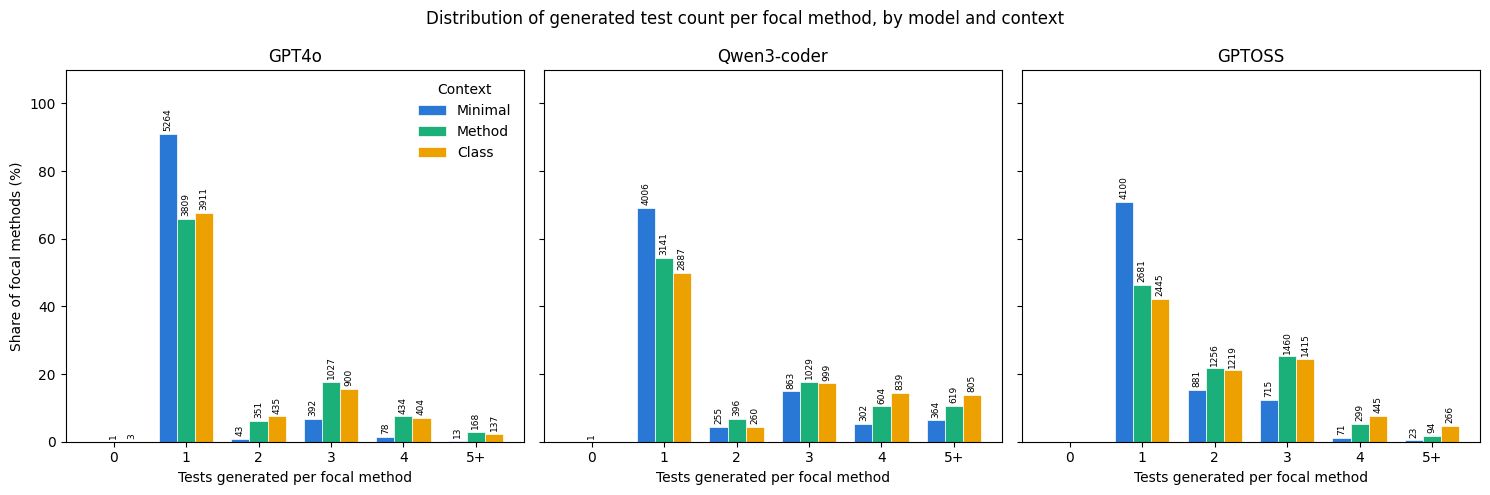

CountBin               0     1     2     3     4    5+
Model       Context                                   
GPT4o       Class    0.1  67.5   7.5  15.5   7.0   2.4
            Method   0.0  65.8   6.1  17.7   7.5   2.9
            Minimal  0.0  90.9   0.7   6.8   1.3   0.2
GPTOSS      Class    0.0  42.2  21.1  24.4   7.7   4.6
            Method   0.0  46.3  21.7  25.2   5.2   1.6
            Minimal  0.0  70.8  15.2  12.3   1.2   0.4
Qwen3-coder Class    0.0  49.9   4.5  17.3  14.5  13.9
            Method   0.0  54.2   6.8  17.8  10.4  10.7
            Minimal  0.0  69.2   4.4  14.9   5.2   6.3

In [12]:
import glob
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_ORDER = ["GPT4o", "Qwen3-coder", "GPTOSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]
# fixed categorical slots (blue/aqua/yellow), assigned in CONTEXT_ORDER - never cycled
CONTEXT_COLORS = {"Minimal": "#2a78d6", "Method": "#1baf7a", "Class": "#eda100"}

per_file_rows = []
for path in glob.glob("output/GeneratedTestCount/*.json"):
    per_file_rows.extend(json.load(open(path, encoding="utf-8")))
per_file_df = pd.DataFrame(per_file_rows)

BIN_LABELS = ["0", "1", "2", "3", "4", "5+"]
per_file_df["CountBin"] = per_file_df["TestCount"].clip(upper=5).astype(str)
per_file_df["CountBin"] = per_file_df["CountBin"].replace({"5": "5+"})

dist = (
    per_file_df.groupby(["Model", "Context", "CountBin"])
    .size()
    .rename("FocalMethodCount")
    .reset_index()
)
group_totals = per_file_df.groupby(["Model", "Context"]).size().rename("Total")
dist = dist.merge(group_totals, on=["Model", "Context"])
dist["SharePct"] = 100 * dist["FocalMethodCount"] / dist["Total"]

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)

bar_width = 0.25
x = np.arange(len(BIN_LABELS))

for ax, model in zip(axes, MODEL_ORDER):
    sub = dist[dist["Model"] == model]
    for i, ctx in enumerate(CONTEXT_ORDER):
        ctx_sub = sub[sub["Context"] == ctx].set_index("CountBin").reindex(BIN_LABELS).fillna(0)
        bars = ax.bar(
            x + (i - 1) * bar_width, ctx_sub["SharePct"], width=bar_width,
            color=CONTEXT_COLORS[ctx], label=ctx if ax is axes[0] else None,
            edgecolor="white", linewidth=0.5,
        )
        for bar, count in zip(bars, ctx_sub["FocalMethodCount"]):
            if count <= 0:
                continue
            ax.annotate(
                f"{int(count)}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 2), textcoords="offset points",
                ha="center", va="bottom", fontsize=6.5, rotation=90,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(BIN_LABELS)
    ax.set_title(model)
    ax.set_xlabel("Tests generated per focal method")

axes[0].set_ylabel("Share of focal methods (%)")
axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.15)
axes[0].legend(title="Context", frameon=False)

fig.suptitle("Distribution of generated test count per focal method, by model and context")
fig.tight_layout()
plt.savefig("output/testcount_per_focalmethod_bar_by_model_context.png", dpi=150, bbox_inches="tight")
plt.show()

# table view (relief rule for the aqua/yellow slots' sub-3:1 light-surface contrast)
dist.pivot_table(index=["Model", "Context"], columns="CountBin", values="SharePct", fill_value=0)[BIN_LABELS].round(1)


Same per-focal-method distribution, extended to the Compiled/Executed/Detected stages (not just Generated). For each of the 5790 focal-method files per (model, context):
- **Compiled**: reuses the corrected generated `TestCount` for that file if it appears in that run's `compile_results_pre.json` "compiled" list, else 0 (failed to compile, or its instance never reached the compile stage).
- **Executed**: the real "Tests run: N" count parsed from that file's `pre/logs/*_execute.log`, only if it's in "passed" - else 0.
- **Detected**: the real failure+error count derived from `transplant_results_breaking_single_module.json`, only if the file appears in that run's "failed" (breaking-change-detecting) list - else 0.

In [13]:
import glob
import json

import pandas as pd

import count_compiled_tests as compiled_mod
import count_executed_tests as executed_mod
import count_detect_tests as detect_mod


def java_filename(test_file_name):
    """'BBC03U0Test_prompt.txt' -> 'BBC03U0Test.java'"""
    return test_file_name.removesuffix("_prompt.txt") + ".java"


def context_dir_for(context_label):
    for context_dir, label in compiled_mod.CONTEXTS.items():
        if label == context_label:
            return context_dir
    raise KeyError(context_label)


def build_compiled_lookup():
    """(context_dir, model_label) -> {instance: set of compiled .java filenames}"""
    lookup = {}
    for key, path in compiled_mod.COMPILE_RESULTS_PATHS.items():
        if not path.exists():
            continue
        data = json.load(open(path, encoding="utf-8"))
        lookup[key] = {
            instance: set(info.get("compiled", []))
            for instance, info in data["compilation_results"].items()
        }
    return lookup


def build_executed_lookup():
    """(context_dir, model_label) -> {instance: {filename: test_case_count}}"""
    lookup = {}
    for key, pre_dir in executed_mod.PRE_DIRS.items():
        json_path = pre_dir / "execute_results_pre.json"
        if not json_path.exists():
            continue
        data = json.load(open(json_path, encoding="utf-8"))
        logs_dir = pre_dir / "logs"
        per_instance = {}
        for instance, idata in data["execution_results"].items():
            per_file = {}
            for test_file in idata.get("passed", []):
                cases = executed_mod.count_test_cases(logs_dir, instance, test_file)
                if cases is not None:
                    per_file[test_file] = cases
            per_instance[instance] = per_file
        lookup[key] = per_instance
    return lookup


def build_detected_lookup():
    """(context_dir, model_label) -> {instance: {filename: detected_case_count}}"""
    lookup = {}
    for key, bre_dir in detect_mod.BRE_DIRS.items():
        json_path = bre_dir / "transplant_results_breaking_single_module.json"
        if not json_path.exists():
            continue
        data = json.load(open(json_path, encoding="utf-8"))
        per_instance = {}
        for instance, tdata in data["results"].items():
            per_file = {}
            for entry in tdata["tests"]["failed"]:
                cases, _used_fallback = detect_mod.count_detected_cases(entry)
                per_file[entry["file"]] = per_file.get(entry["file"], 0) + cases
            per_instance[instance] = per_file
        lookup[key] = per_instance
    return lookup


generated_rows = []
for path in glob.glob("output/GeneratedTestCount/*.json"):
    generated_rows.extend(json.load(open(path, encoding="utf-8")))

compiled_lookup = build_compiled_lookup()
executed_lookup = build_executed_lookup()
detected_lookup = build_detected_lookup()

stage_rows = {"Compiled": [], "Executed": [], "Detected": []}
for row in generated_rows:
    model, context, instance = row["Model"], row["Context"], row["Instance"]
    java_file = java_filename(row["TestFileName"])
    key = (context_dir_for(context), model)

    compiled_files = compiled_lookup.get(key, {}).get(instance, set())
    stage_rows["Compiled"].append({**row, "TestCount": row["TestCount"] if java_file in compiled_files else 0})

    executed_files = executed_lookup.get(key, {}).get(instance, {})
    stage_rows["Executed"].append({**row, "TestCount": executed_files.get(java_file, 0)})

    detected_files = detected_lookup.get(key, {}).get(instance, {})
    stage_rows["Detected"].append({**row, "TestCount": detected_files.get(java_file, 0)})

stage_dfs = {stage: pd.DataFrame(rows) for stage, rows in stage_rows.items()}
for stage, sdf in stage_dfs.items():
    print(stage, "-> sum TestCount:", sdf["TestCount"].sum(), "| nonzero rows:", (sdf["TestCount"] > 0).sum(), "/", len(sdf))


Compiled -> sum TestCount: 17429 | nonzero rows: 10500 / 52110
Executed -> sum TestCount: 9033 | nonzero rows: 5689 / 52110
Detected -> sum TestCount: 3754 | nonzero rows: 3036 / 52110


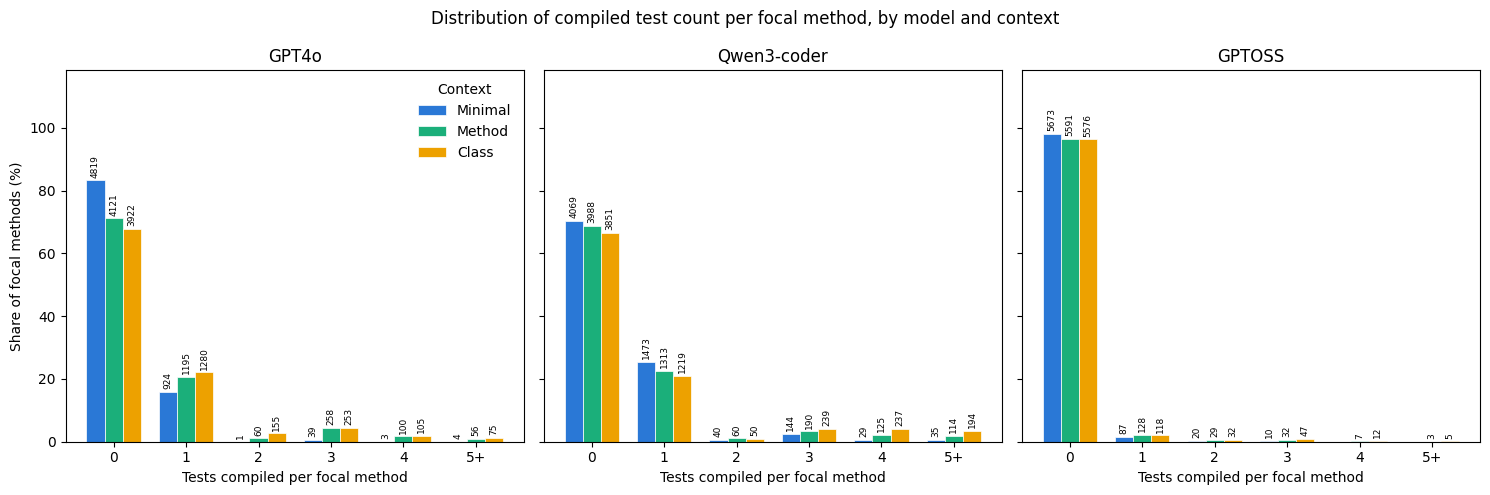

CountBin                0     1    2    3    4   5+
Model       Context                                
GPT4o       Class    67.7  22.1  2.7  4.4  1.8  1.3
            Method   71.2  20.6  1.0  4.5  1.7  1.0
            Minimal  83.2  16.0  0.0  0.7  0.1  0.1
GPTOSS      Class    96.3   2.0  0.6  0.8  0.2  0.1
            Method   96.6   2.2  0.5  0.6  0.1  0.1
            Minimal  98.0   1.5  0.3  0.2  0.0  0.0
Qwen3-coder Class    66.5  21.1  0.9  4.1  4.1  3.4
            Method   68.9  22.7  1.0  3.3  2.2  2.0
            Minimal  70.3  25.4  0.7  2.5  0.5  0.6

In [14]:
import numpy as np
import matplotlib.pyplot as plt

MODEL_ORDER = ["GPT4o", "Qwen3-coder", "GPTOSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]
CONTEXT_COLORS = {"Minimal": "#2a78d6", "Method": "#1baf7a", "Class": "#eda100"}
BIN_LABELS = ["0", "1", "2", "3", "4", "5+"]


def plot_stage_distribution(stage_df, stage_name):
    df = stage_df.copy()
    df["CountBin"] = df["TestCount"].clip(upper=5).astype(str).replace({"5": "5+"})

    dist = (
        df.groupby(["Model", "Context", "CountBin"])
        .size()
        .rename("FocalMethodCount")
        .reset_index()
    )
    totals = df.groupby(["Model", "Context"]).size().rename("Total")
    dist = dist.merge(totals, on=["Model", "Context"])
    dist["SharePct"] = 100 * dist["FocalMethodCount"] / dist["Total"]

    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)
    bar_width = 0.25
    x = np.arange(len(BIN_LABELS))

    for ax, model in zip(axes, MODEL_ORDER):
        sub = dist[dist["Model"] == model]
        for i, ctx in enumerate(CONTEXT_ORDER):
            ctx_sub = sub[sub["Context"] == ctx].set_index("CountBin").reindex(BIN_LABELS).fillna(0)
            bars = ax.bar(
                x + (i - 1) * bar_width, ctx_sub["SharePct"], width=bar_width,
                color=CONTEXT_COLORS[ctx], label=ctx if ax is axes[0] else None,
                edgecolor="white", linewidth=0.5,
            )
            for bar, count in zip(bars, ctx_sub["FocalMethodCount"]):
                if count <= 0:
                    continue
                ax.annotate(
                    f"{int(count)}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 2), textcoords="offset points",
                    ha="center", va="bottom", fontsize=6.5, rotation=90,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(BIN_LABELS)
        ax.set_title(model)
        ax.set_xlabel(f"Tests {stage_name.lower()} per focal method")

    axes[0].set_ylabel("Share of focal methods (%)")
    axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.15)
    axes[0].legend(title="Context", frameon=False)

    fig.suptitle(f"Distribution of {stage_name.lower()} test count per focal method, by model and context")
    fig.tight_layout()
    out_path = f"output/testcount_per_focalmethod_bar_{stage_name.lower()}_by_model_context.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    return dist.pivot_table(index=["Model", "Context"], columns="CountBin", values="SharePct", fill_value=0)[BIN_LABELS].round(1)


plot_stage_distribution(stage_dfs["Compiled"], "Compiled")


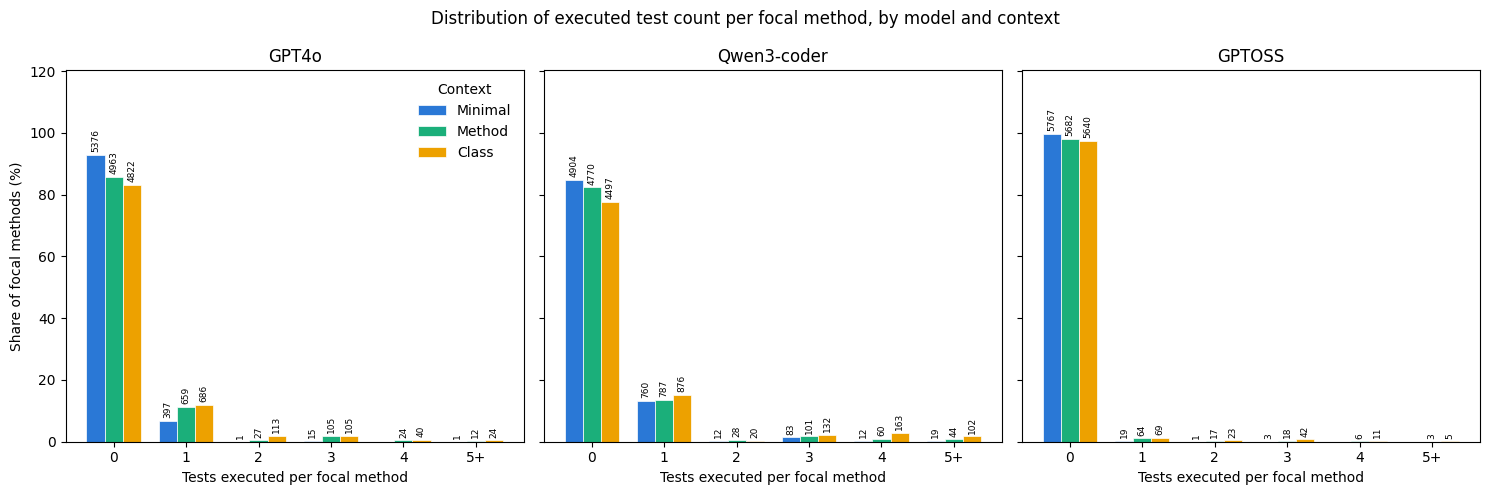

CountBin                0     1    2    3    4   5+
Model       Context                                
GPT4o       Class    83.3  11.8  2.0  1.8  0.7  0.4
            Method   85.7  11.4  0.5  1.8  0.4  0.2
            Minimal  92.8   6.9  0.0  0.3  0.0  0.0
GPTOSS      Class    97.4   1.2  0.4  0.7  0.2  0.1
            Method   98.1   1.1  0.3  0.3  0.1  0.1
            Minimal  99.6   0.3  0.0  0.1  0.0  0.0
Qwen3-coder Class    77.7  15.1  0.3  2.3  2.8  1.8
            Method   82.4  13.6  0.5  1.7  1.0  0.8
            Minimal  84.7  13.1  0.2  1.4  0.2  0.3

In [15]:
plot_stage_distribution(stage_dfs["Executed"], "Executed")


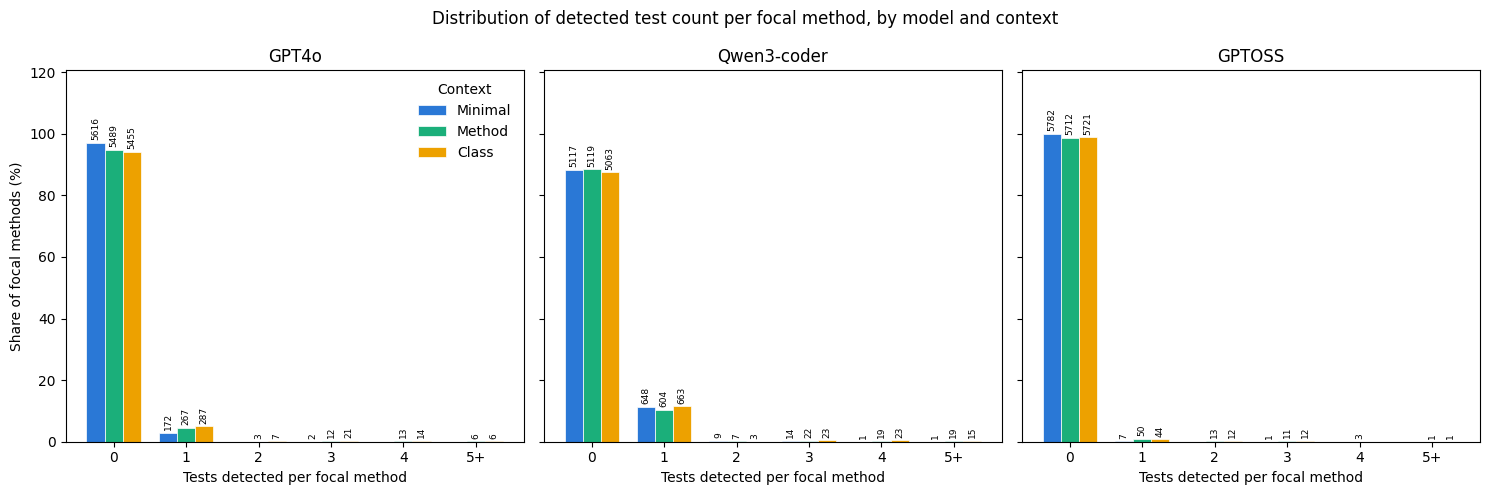

CountBin                0     1    2    3    4   5+
Model       Context                                
GPT4o       Class    94.2   5.0  0.1  0.4  0.2  0.1
            Method   94.8   4.6  0.1  0.2  0.2  0.1
            Minimal  97.0   3.0  0.0  0.0  0.0  0.0
GPTOSS      Class    98.8   0.8  0.2  0.2  0.0  0.0
            Method   98.7   0.9  0.2  0.2  0.1  0.0
            Minimal  99.9   0.1  0.0  0.0  0.0  0.0
Qwen3-coder Class    87.4  11.5  0.1  0.4  0.4  0.3
            Method   88.4  10.4  0.1  0.4  0.3  0.3
            Minimal  88.4  11.2  0.2  0.2  0.0  0.0

In [16]:
plot_stage_distribution(stage_dfs["Detected"], "Detected")
